# Week 3 시계열 데이터 과제

- **이론:** 정규 세션 핵심 내용 기반 주관식 2문제
- **실습:** ARIMA & DLinear 모델 활용 및 분석
<br><br> 모르는 부분 혹은 문제에 오류가 있는 경우 **24기_이용선** 으로 편하게 연락주세요:)

## 이론
- 정규세션의 핵심 내용을 기반으로 하여 출제한 주관식 문제입니다.

Q1. 시계열 데이터에서 정상성이 중요한 이유와 ARIMA 모델이 데이터의 비정상성을 처리하는 방법을 서술하시오.

A1.

Q2. 어떤 시계열의 특성이 다음과 같다. 해당 시계열의 **정상성 여부를 판단하고, 적절한 모형을 제시하시오.**
- 원 시계열 ACF는 매우 천천히 감소
- PACF는 1시차에서 큰 값 이후 점진적으로 감소
- 1차 차분 후 ACF는 절단 형태를 보임
- 차분 후 PACF는 점진적으로 감소
- 분산은 시간에 따라 변하지 않음

A2.

## 실습

- 사용하는 데이터는 [kaggle의 2차 세계대전 날씨 데이터](https://www.kaggle.com/datasets/smid80/weatherww2)입니다.
- 주어진 데이터를 활용하여 코드 중간중간 주어진 문제에 답해주세요.

### 데이터 전처리

In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("smid80/weatherww2")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'weatherww2' dataset.
Path to dataset files: /kaggle/input/weatherww2


In [12]:
# kaggle 데이터 로드
import os

path = "/kaggle/input/weatherww2"
print(os.listdir(path))

['Summary of Weather.csv', 'Weather Station Locations.csv']


In [15]:
# station별 위치 정보 데이터(위도, 경도 등)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

loc_df = pd.read_csv("/kaggle/input/weatherww2/Weather Station Locations.csv")
# 필요한 열들만 불러옴
loc_df = loc_df.loc[:, ["WBAN", "NAME", "STATE/COUNTRY ID", "Latitude", "Longitude"]]


loc_df.head()

,WBAN,NAME,STATE/COUNTRY ID,Latitude,Longitude
0,33013,AIN EL,AL,36.383333,6.650000
1,33031,LA SENIA,AL,35.616667,0.583333
2,33023,MAISON BLANCHE,AL,36.716667,3.216667
3,33044,TELERGMA,AL,36.116667,6.416667
4,12001,TINDOUF,AL,27.683333,-8.083333


In [16]:
# station별 실제 날씨 데이터
weather_df = pd.read_csv("/kaggle/input/weatherww2/Summary of Weather.csv")

# 필요한 열들만 불러옴
weather_df = weather_df.loc[:, ["STA", "Date", "MaxTemp", "MinTemp", "MeanTemp", "Precip"]]

# 데이터 정제: "T", 비가 측정할 수 없을 정도로 미미하게 옴을 의미함
# "T"로 인해 나머지 수치형 데이터가 범주형으로 취급받고 있으므로 "T" 를 수치형 값(ex.0.1, 0.01)으로 변환함
weather_df["Precip"] = weather_df["Precip"].replace("T", 0.1)
# 숫자로 변환 (문자 → float)
weather_df["Precip"] = pd.to_numeric(weather_df["Precip"], errors="coerce")


weather_df.head()

/tmp/ipykernel_572/1049732682.py:2: DtypeWarning: Columns (7,8,18,25) have mixed types. Specify dtype option on import or set low_memory=False.
  weather_df = pd.read_csv("/kaggle/input/weatherww2/Summary of Weather.csv")


,STA,Date,MaxTemp,MinTemp,MeanTemp,Precip
0,10001,1942-7-1,25.555556,22.222222,23.888889,1.016
1,10001,1942-7-2,28.888889,21.666667,25.555556,0.000
2,10001,1942-7-3,26.111111,22.222222,24.444444,2.540
3,10001,1942-7-4,26.666667,22.222222,24.444444,2.540
4,10001,1942-7-5,26.666667,21.666667,24.444444,0.000


### 데이터 준비
- ARIMA는 자기 자신의 과거 값만으로 예측하는 모델이기 때문에 시간 순서와 예측할 하나의 값(예: 기온, 강수량)만을 필요로 합니다.
- 이번 실습에서는 **AGRA** 지역의 **강수량**를 대상으로 진행해보겠습니다.

In [17]:
# weather_df에는 지역 이름 없이 STA라는 관측소 ID만 존재하기 때문에, loc_df에서 지역의 관측소 ID를 찾음
loc_sta = loc_df[loc_df["NAME"] == "AGRA"].WBAN
weather_bin = weather_df[weather_df.STA == int(loc_sta)]
weather_bin["Date"] = pd.to_datetime(weather_bin["Date"])
weather_bin

/tmp/ipykernel_572/3926248603.py:3: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  weather_bin = weather_df[weather_df.STA == int(loc_sta)]
/tmp/ipykernel_572/3926248603.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather_bin["Date"] = pd.to_datetime(weather_bin["Date"])


,STA,Date,MaxTemp,MinTemp,MeanTemp,Precip
70653,32701,1942-08-24,32.222222,25.000000,28.888889,0.000
70654,32701,1942-08-25,31.111111,25.555556,28.333333,9.652
70655,32701,1942-08-26,32.222222,25.000000,28.888889,0.762
70656,32701,1942-08-27,32.222222,24.444444,28.333333,19.558
70657,32701,1942-08-28,31.666667,25.555556,28.888889,2.540
...,...,...,...,...,...,...
71873,32701,1945-12-27,21.666667,4.444444,13.333333,0.000
71874,32701,1945-12-28,20.555556,4.444444,12.222222,0.000
71875,32701,1945-12-29,20.555556,4.444444,12.222222,0.000
71876,32701,1945-12-30,20.555556,3.888889,12.222222,0.000


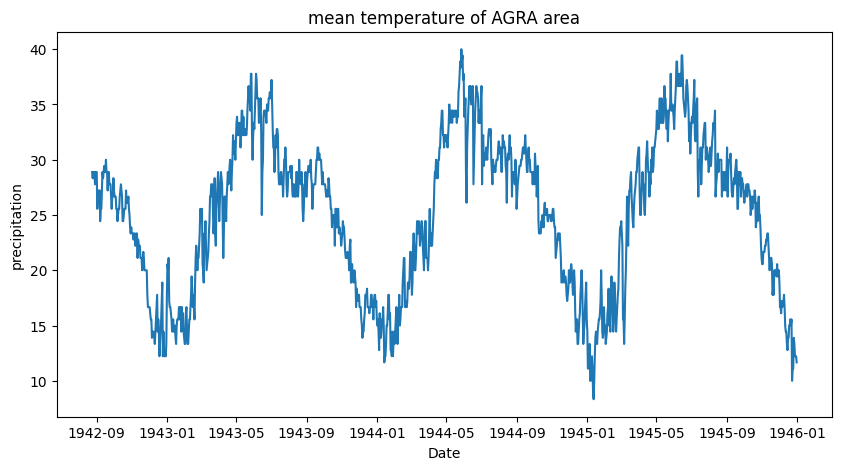

In [18]:
# 해당 지역의 평균 온도
plt.figure(figsize=(10, 5))
plt.plot(weather_bin.Date, weather_bin.MeanTemp)
plt.title("mean temperature of AGRA area")
plt.xlabel("Date")
plt.ylabel("precipitation")
plt.show()

In [19]:
timeSeries = weather_bin.loc[:, ["Date", "MeanTemp"]]
timeSeries.index = timeSeries.Date
ts = timeSeries.drop("Date", axis=1)
ts

,MeanTemp
Date,
1942-08-24,28.888889
1942-08-25,28.333333
1942-08-26,28.888889
1942-08-27,28.333333
1942-08-28,28.888889
...,...
1945-12-27,13.333333
1945-12-28,12.222222
1945-12-29,12.222222


<Figure size 640x480 with 0 Axes>

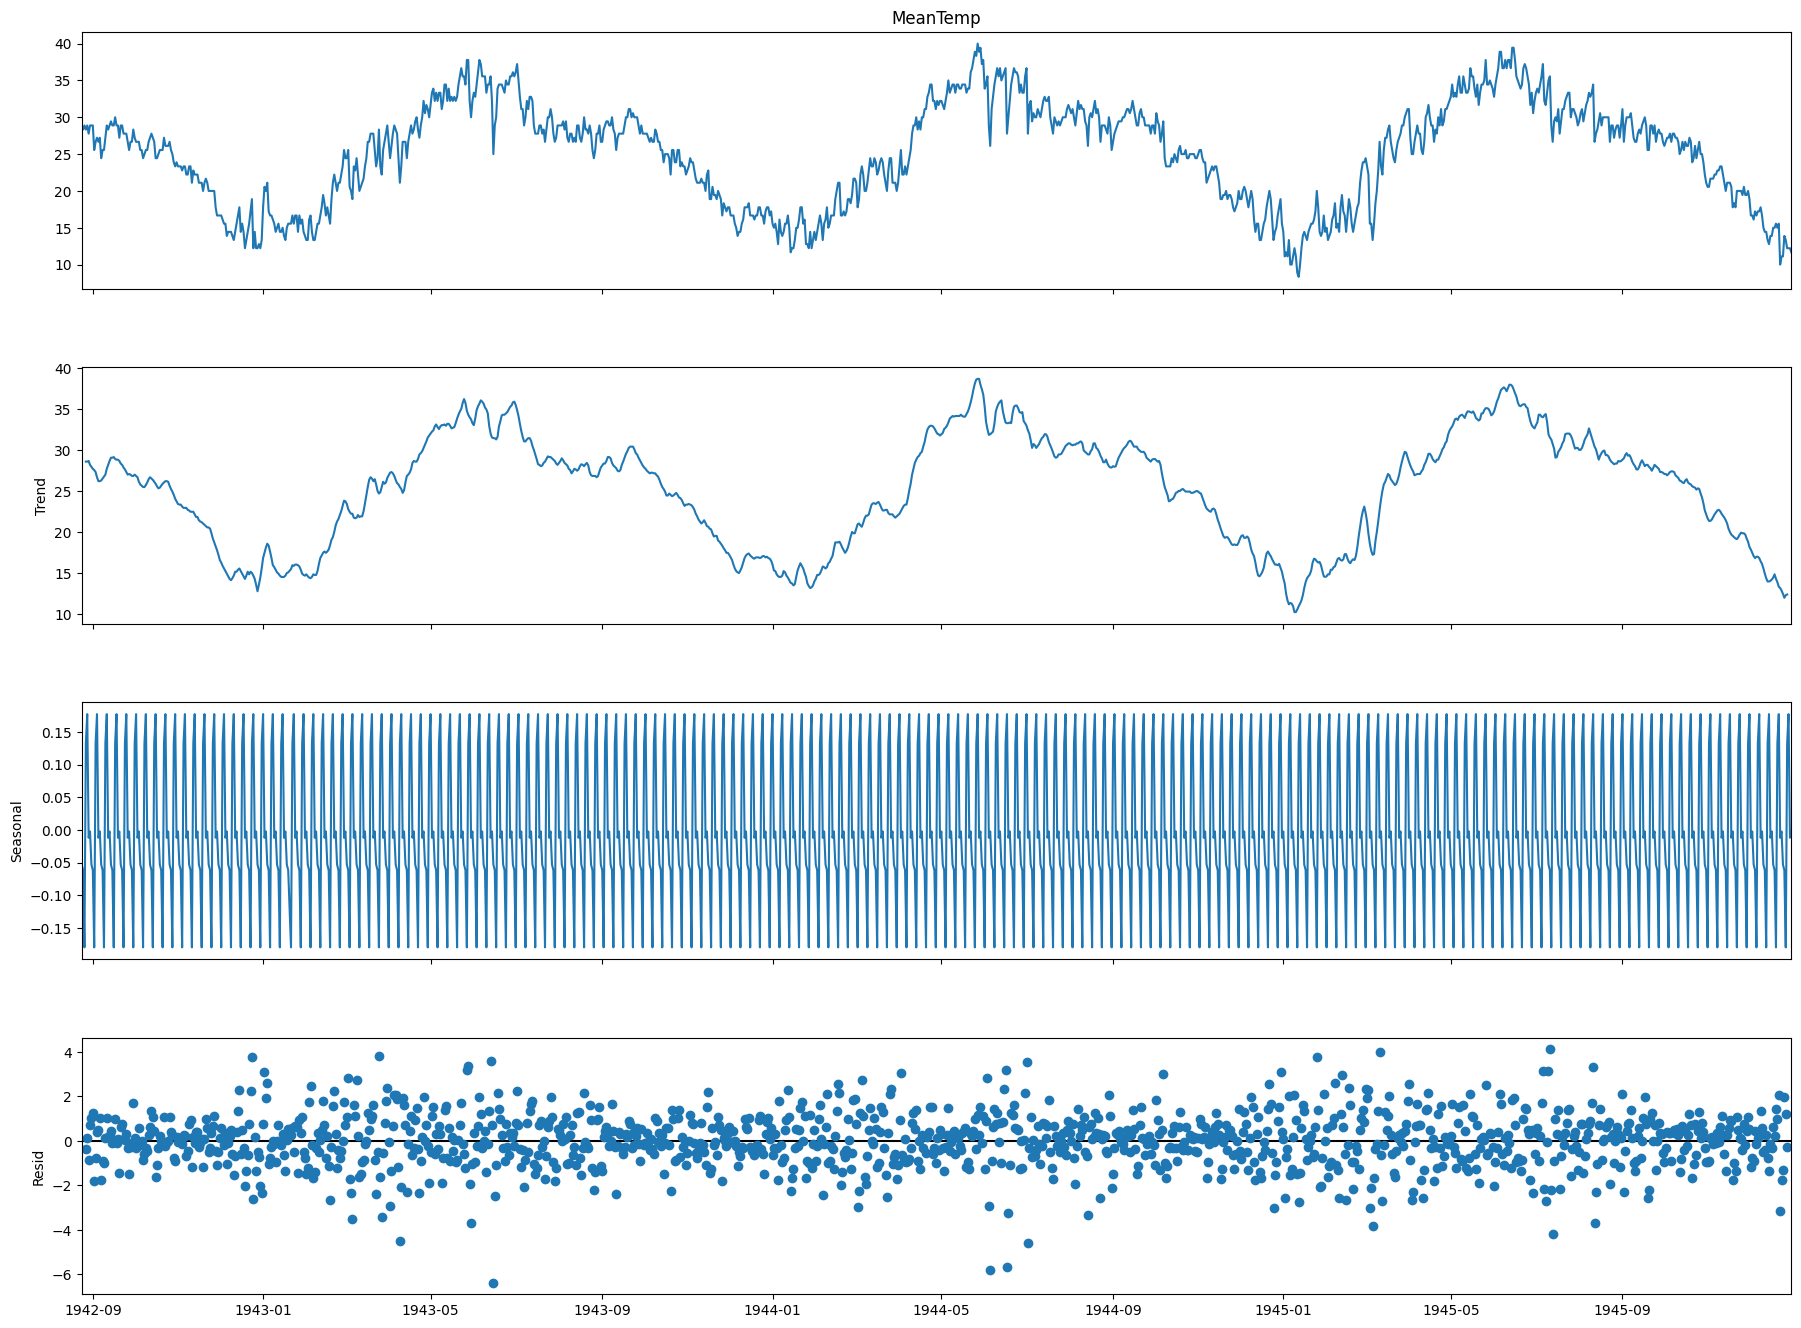

In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 시계열 구성요소별 분리
result = seasonal_decompose(ts["MeanTemp"], model='additive', period=7)

fig = plt.figure()
fig = result.plot()
fig.set_size_inches(20, 15)

### 정상성

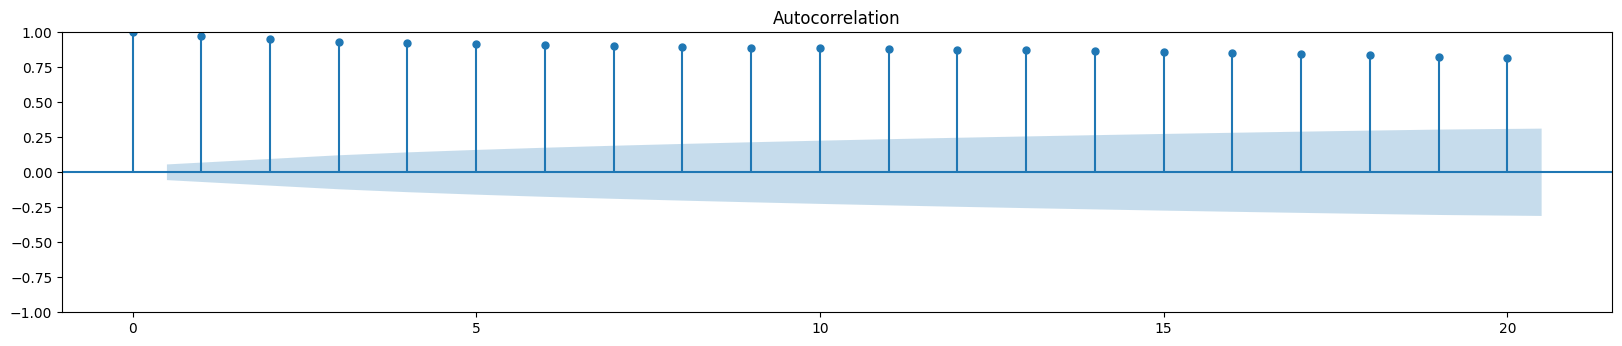

In [21]:
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts, lags=20, ax=ax1)

In [22]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(ts)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -2.062436
p-value: 0.259885
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


Q1. 위 결과를 통해 알 수 있는 것은 무엇인지, 대립가설 혹은 귀무가설이라는 키워드를 사용하여 서술하세요.

A1.

- 귀무가설(H₀): 시계열은 비정상(non-stationary)이다.
- 대립가설(H₁): 시계열은 정상(stationary)이다.

p-value가 0.2599로 0.05보다 크므로 귀무가설을 기각할 수 없다. 즉, 해당 시계열은 비정상 시계열이다. 따라서 차분 등의 정상화 과정이 필요하다.

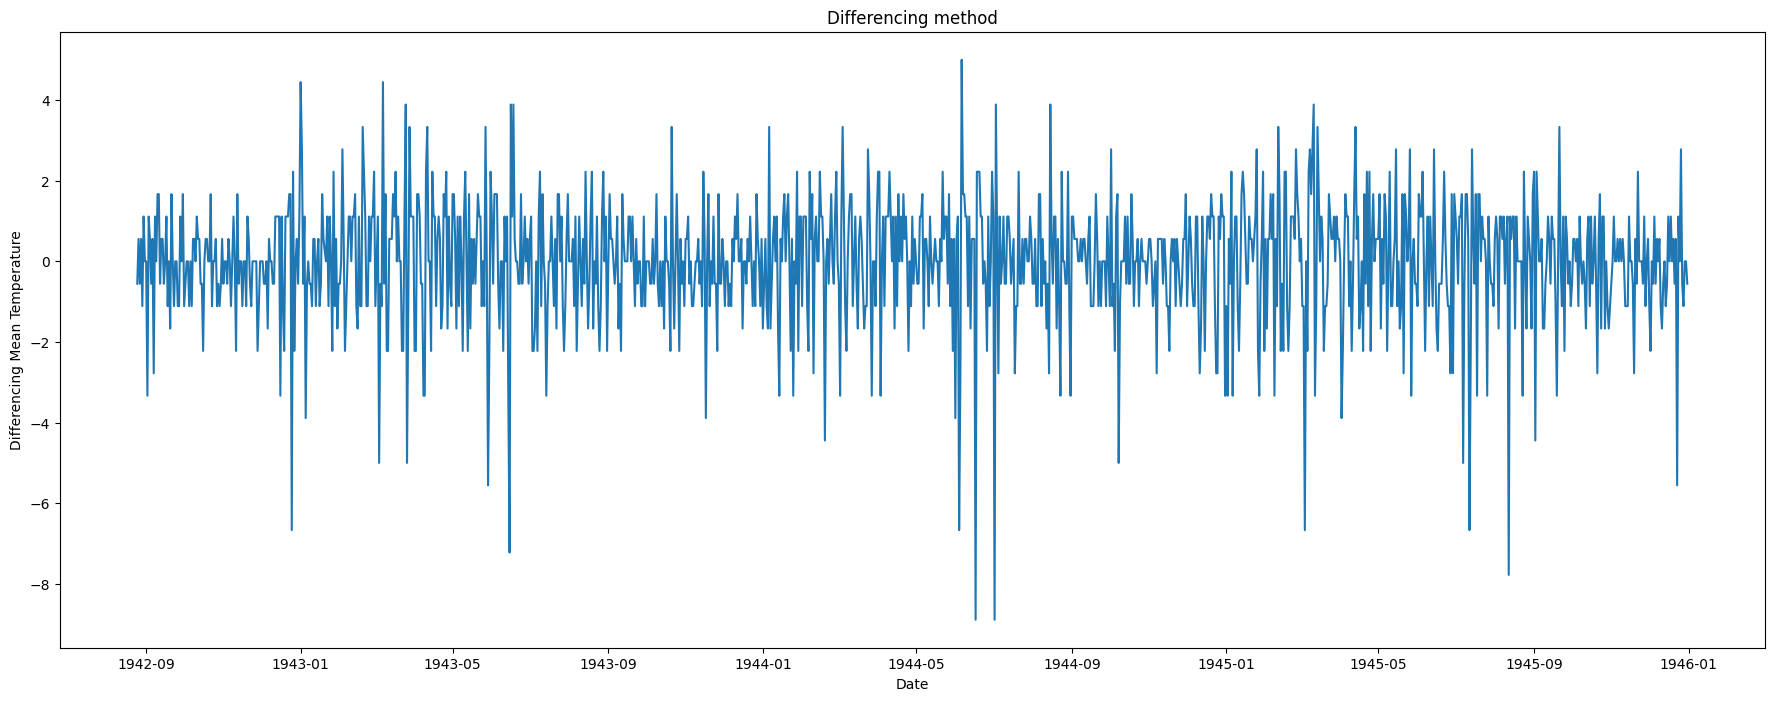

In [23]:
ts_diff = ts - ts.shift()
plt.figure(figsize=(22,8))
plt.plot(ts_diff)
plt.title("Differencing method")
plt.xlabel("Date")
plt.ylabel("Differencing Mean Temperature")
plt.show()

In [24]:
result = adfuller(ts_diff[1:])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -6.294669
p-value: 0.000000
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


Q2. 이전의 결과와 비교했을 때 무엇이 달라졌으며, 그 이유는 무엇인가요?

A2.위 결과는 차분 후의 ADF 검정 결과이다. p-value 가 0.05보다 작으므로 귀무가설을 기각하며, 1차 차분을 통해 정상성을 확보하였다고 할 수 있다.

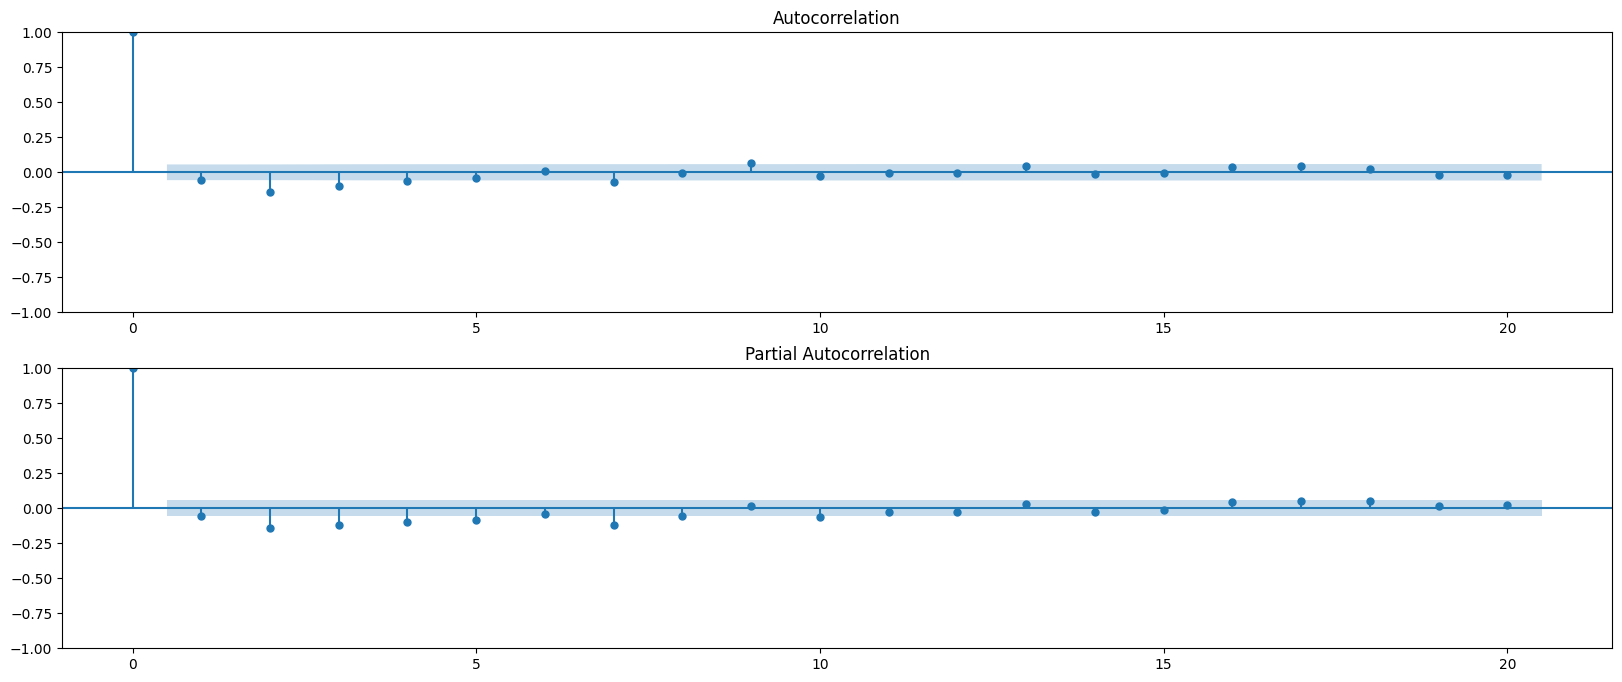

In [25]:
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts_diff[1:], lags=20, ax=ax1)

ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(ts_diff[1:], lags=20, ax=ax2)

Q3. 두 그림이 의미하는 바가 무엇이며, 이를 통해 아래 ARIMA의 하이퍼파라미터인 p와 q를 얼마로 설정해야할지 그 숫자와 근거를 적어주세요. 이후 변수를 선언해주세요.

A3.

위 그림은 차분된 시계열의 ACF(위), PACF(아래) 그림이다.

ACF는 시차(lag)별 자기상관(autocorrelation)을 보여주고, q 판단 기준이 된다. 본 그림에서는 ACF가 lag1에서 급격히 끊기므로, q=1이 적절하다.

PACF는 다른 시차 영향을 제거한 순수 자기상관으로 p 판단 기준이 된다. 본 그림에서는 PACF가 lag1에서 급격히 끊기므로 p=1이 적절하다.

따라서 최종 선택 모델은 ARIMA(1,1,1)이다.

### ARIMA

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


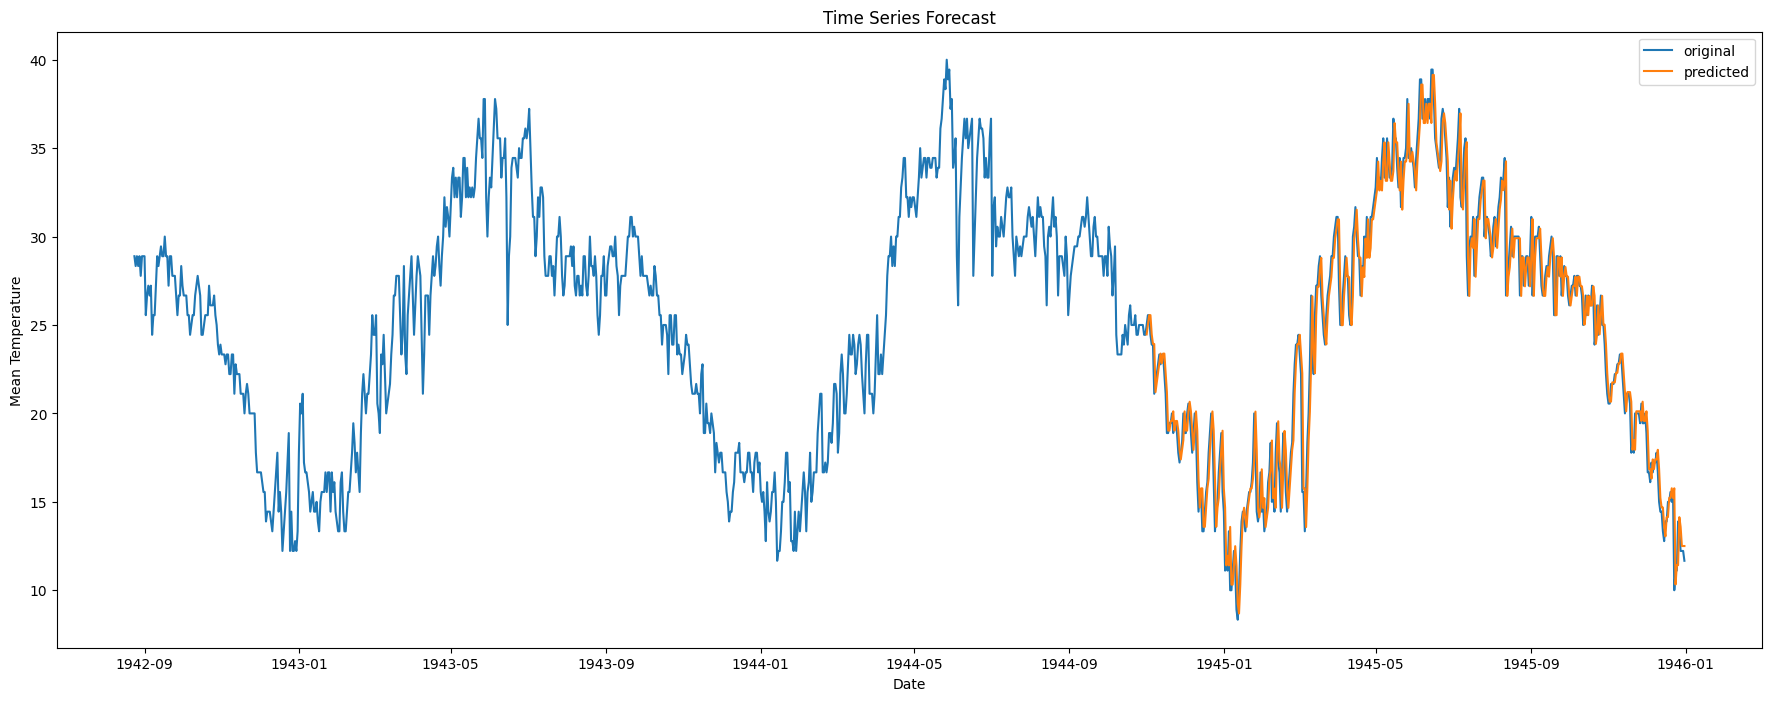

In [26]:
from statsmodels.tsa.arima.model import ARIMA
from datetime import datetime

## fit_this_code
p = 1
d = 1
q = 1

# fit model
model = ARIMA(ts, order=(p,d,q))
model_fit = model.fit()

# predict
start_index = datetime(1944, 11, 1)
end_index = datetime(1945, 12, 31)
forecast = model_fit.predict(start=start_index, end=end_index, typ='levels')

# visualization
plt.figure(figsize=(22,8))
plt.plot(weather_bin.Date, weather_bin.MeanTemp, label="original")
plt.plot(forecast, label="predicted")
plt.title("Time Series Forecast")
plt.xlabel("Date")
plt.ylabel("Mean Temperature")
plt.legend()
plt.show()

/tmp/ipykernel_572/1273724452.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


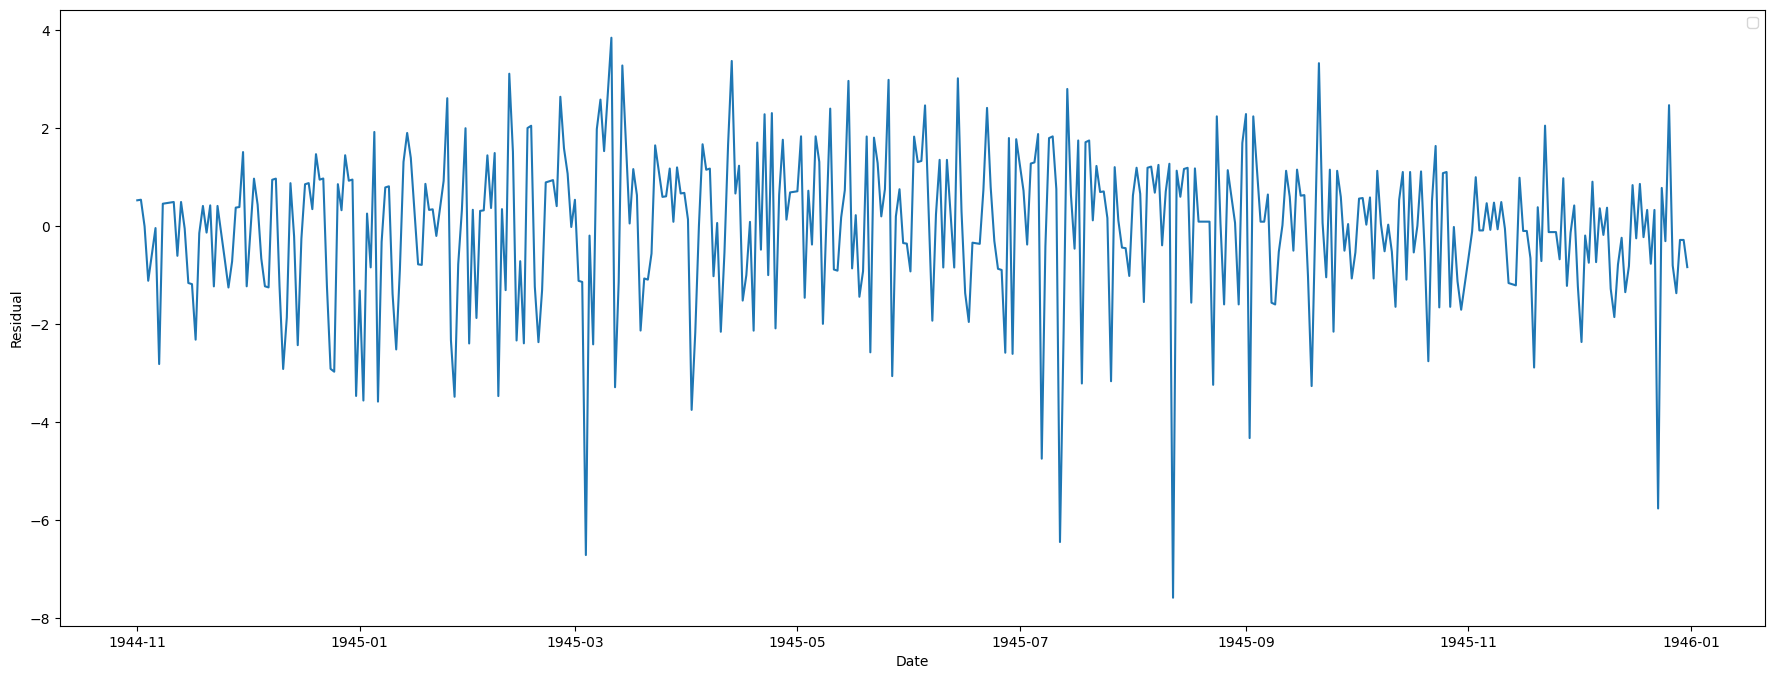

In [27]:
# 잔차 분석
resi = np.array(weather_bin[weather_bin.Date >= start_index].MeanTemp) - np.array(forecast)

plt.figure(figsize=(22,8))
plt.plot(weather_bin.Date[weather_bin.Date >= start_index], resi)
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.show()

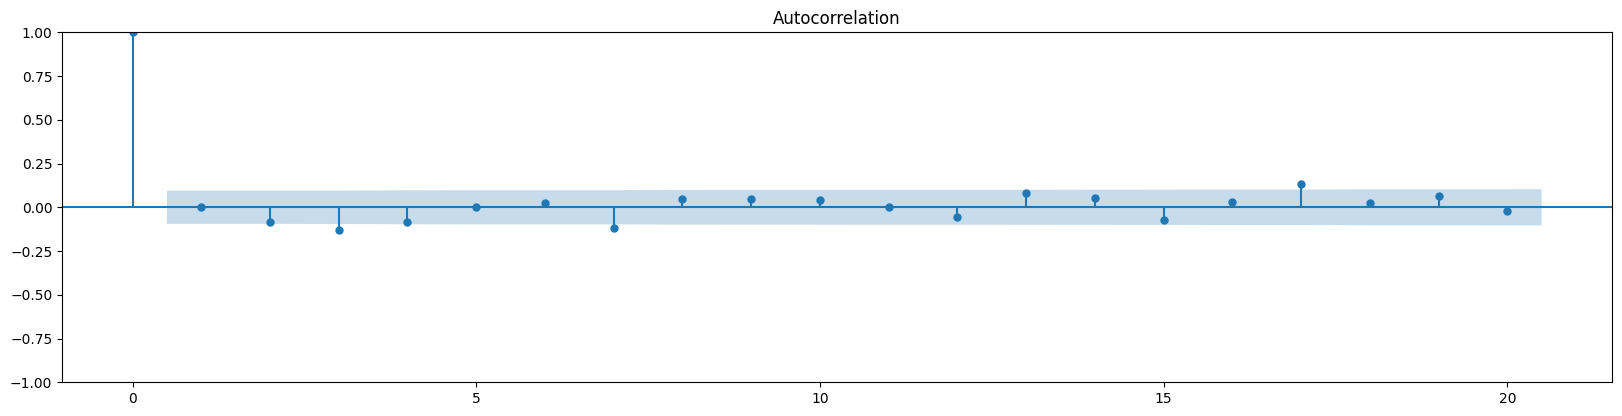

In [28]:
fig = plt.figure(figsize=(20,10))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(resi, lags=20, ax=ax1)

In [29]:
result = adfuller(resi)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
  print('\t%s: %.3f' % (key, value))

ADF Statistic: -3.899484
p-value: 0.002039
Critical Values:
	1%: -3.446
	5%: -2.869
	10%: -2.571


In [30]:
from sklearn import metrics

def scoring(y_true, y_pred):
  r2 = round(metrics.r2_score(y_true, y_pred) * 100, 3)
  corr = round(np.corrcoef(y_true, y_pred)[0, 1], 3)
  mape = round(
    metrics.mean_absolute_percentage_error(y_true, y_pred) * 100, 3
  )
  rmse = round(
    np.sqrt(metrics.mean_squared_error(y_true, y_pred)), 3
  )

  df = pd.DataFrame({
    "R2": r2,
    "Corr": corr,
    "RMSE": rmse,
    "MAPE": mape
  }, index=[0])

  return df

In [31]:
scoring(np.array(weather_bin[weather_bin.Date >= start_index].MeanTemp), np.array(forecast))

,R2,Corr,RMSE,MAPE
0,95.589,0.978,1.56,5.426


Q4. 해당 결과가 의미하는 바가 무엇인지 서술하시오.

A4.
R2=95.589 이므로 모델이 실제 값의 약 95.6%의 분산을 설명하고 있다. 즉 매우 높은 설명력을 가진다.

Corr는 상관계수로, 이 값이 0.978이라는 것은 예측값과 실제값 사이에 매우 강한 양의 선형 관계가 존재한다는 것이다. 즉, 실제값이 예측 추세를 매우 잘 따라간다고 볼 수 있다.

RMSE=1.56은 평균적으로 약 1.56정도의 오차가 발생한다는 것이며, 온도 단위 기준으로 보면 오차 규모가 작은 편이다.

MAPE=5.426은 평균 절대 오차 비율이 약 5.4%라는 의미이다. 일반적으로 10% 이하면 우수한 예측 성능으로 평가되므로, 본 예측은 성능이 매우 우수하다고 판단할 수 있다.



### DLinear
Q4. DLinear 모델은 kernel, learning rate, epoch 등 여러 하이퍼파라미터가 존재합니다. 아래 코드에서 각 하이퍼파라미터를 직접 조정하시며 가장 좋은 결과가 나온 값을 작성해주세요. 또한 그 값이 좋은 결과라고 판단하게 된 근거를 작성해주세요. (ex. 에러율, 시각화 결과 등) 마지막으로, ARIMA와 비교하여 해당 데이터셋에서는 어느 모델이 더 적합한 것 같은지 모델의 이름과 그 이유를 작성해주세요.

A4.
다음은 learning rate=0.001, epoch=100으로 조정한 결과이다.

해당 결과는 예측값과 실제값 간의 상관관계가 약 77%이며, 평균 오차율이 약 10.65% 수준으로 비교적 안정적인 예측 성능을 보였다.
특히 learning rate를 0.01에서 0.001로 낮추었을 때 학습이 보다 안정적으로 수렴하였고, epoch을 100까지 증가시킴으로써 충분한 학습이 이루어졌다.

이전에 적용한 ARIMA 모델의 성능(R²≈95%, RMSE≈1.56, MAPE≈5.4%)과 비교하면,
ARIMA가 DLinear보다 더 낮은 오차와 높은 설명력을 보였다.

따라서 본 데이터셋에서는
ARIMA 모델이 DLinear보다 더 적합한 모델이라고 판단된다.

In [32]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [33]:
data = ts.values

train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [34]:
seq_len = 365 # 입력 길이
pred_len = 30 # 예측 길이

class TimeSeriesDataset(Dataset):
  def __init__(self, data, seq_len, pred_len):
    self.data = data
    self.seq_len = seq_len
    self.pred_len = pred_len

  def __len__(self):
    return len(self.data) - self.seq_len - self.pred_len

  def __getitem__(self, idx):
    x = self.data[idx:idx+self.seq_len]
    y = self.data[idx+self.seq_len:idx+self.seq_len+self.pred_len]
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

train_dataset = TimeSeriesDataset(train_scaled, seq_len, pred_len)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

In [35]:
class DLinear(nn.Module):
  def __init__(self, seq_len, pred_len, kernel_size=365):
    super().__init__()

    self.moving_avg = nn.AvgPool1d(
        kernel_size=kernel_size,
        stride=1,
        padding=kernel_size//2
    )

    self.linear_seasonal = nn.Linear(seq_len, pred_len)
    self.linear_trend = nn.Linear(seq_len, pred_len)

  def series_decomp(self, x):
    x = x.permute(0, 2, 1)
    trend = self.moving_avg(x)
    seasonal = x - trend
    return seasonal, trend

  def forward(self, x):
    seasonal, trend = self.series_decomp(x)
    seasonal = seasonal.squeeze(1)
    trend = trend.squeeze(1)
    return self.linear_seasonal(seasonal) + self.linear_trend(trend)

In [36]:
model = DLinear(seq_len, pred_len).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 100

for epoch in range(epochs):
  model.train()
  total_loss = 0

  for x, y in train_loader:
    x, y = x.to(device), y.to(device)

    optimizer.zero_grad()
    output = model(x)
    loss = criterion(output, y.squeeze(-1))
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  if (epoch+1) % 10 == 0:
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.6f}")

Epoch 10, Loss: 0.005217
Epoch 20, Loss: 0.004706
Epoch 30, Loss: 0.003889
Epoch 40, Loss: 0.003993
Epoch 50, Loss: 0.004381
Epoch 60, Loss: 0.003841
Epoch 70, Loss: 0.003473
Epoch 80, Loss: 0.003553
Epoch 90, Loss: 0.003547
Epoch 100, Loss: 0.003339


In [37]:
model.eval()

predictions = []

# walk-Forward Validation 방식으로 예측
# 시작 window: train 마지막 seq_len
current_window = train_scaled[-seq_len:].copy()

total_test_len = len(test_scaled)

while len(predictions) < total_test_len:

  x = torch.tensor(current_window, dtype=torch.float32).unsqueeze(0).to(device)

  with torch.no_grad():
    pred = model(x).cpu().numpy().flatten()

  # 남은 길이보다 많이 예측했으면 자르기
  remaining = total_test_len - len(predictions)
  pred = pred[:remaining]

  predictions.extend(pred)

  # window 업데이트 (예측값 붙이고 앞에서 제거)
  current_window = np.concatenate(
    [current_window[pred_len:], pred.reshape(-1,1)],
    axis=0
  )

# 역정규화
forecast_dl = scaler.inverse_transform(np.array(predictions).reshape(-1,1))

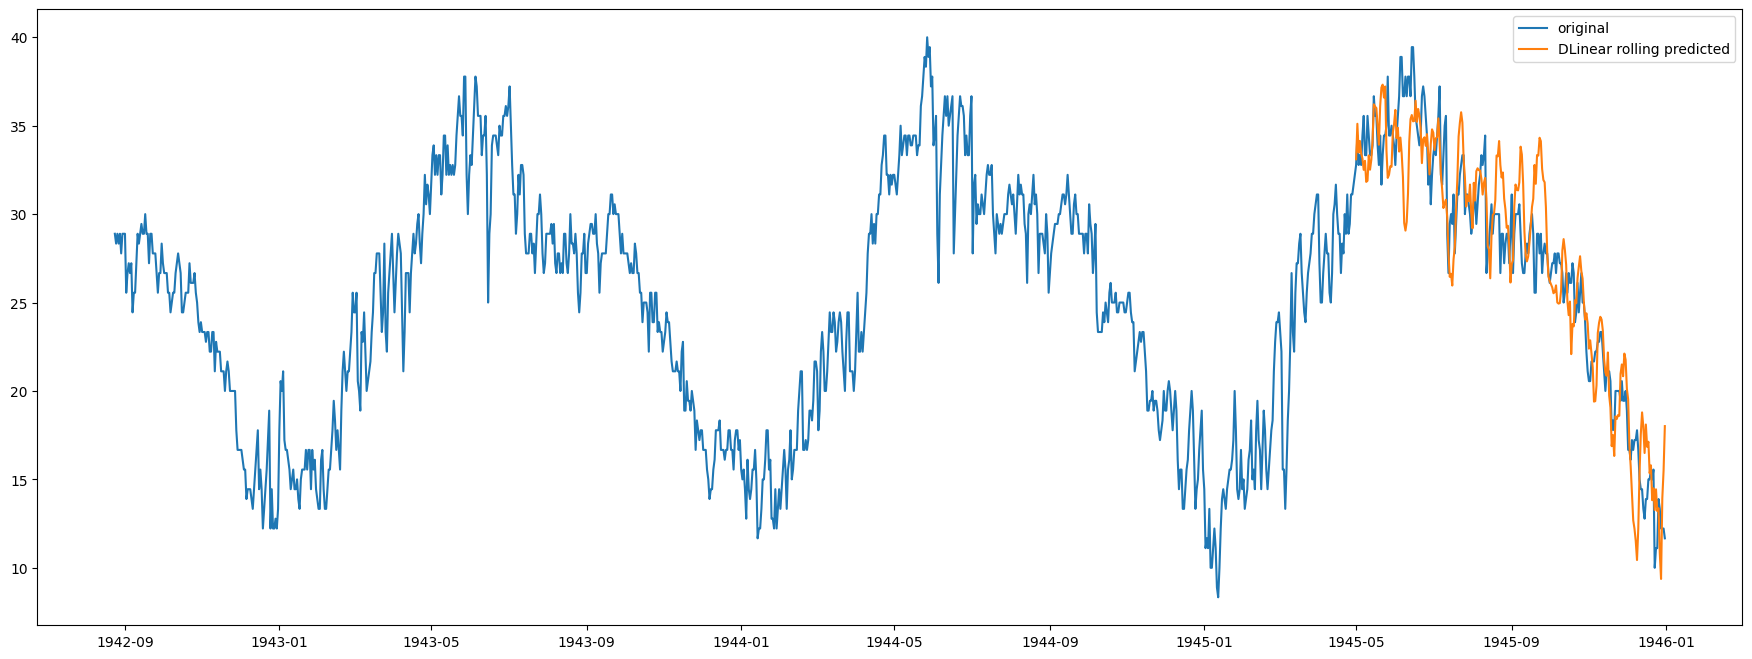

In [38]:
plt.figure(figsize=(22,8))
plt.plot(ts.index, ts.values, label="original")

test_dates = ts.index[train_size:]
plt.plot(test_dates, forecast_dl.flatten(),label="DLinear rolling predicted")

plt.legend()
plt.show()

In [39]:
test_start_idx = train_size

y_true = ts.values[test_start_idx:].reshape(-1)
y_pred = forecast_dl.reshape(-1)

print(y_true.shape, y_pred.shape)

scoring(y_true, y_pred)

(245,) (245,)


,R2,Corr,RMSE,MAPE
0,84.135,0.919,2.75,8.521


## 추가실습

- AGRA 지역의 강수량 분석과는 별도로, 도시와 분석 요인을 자율적으로 선정하여 동일한 분석 과정을 수행하세요.
- 원활한 진행을 위해 데이터가 충분히 확보된 도시 리스트를 제공합니다.
- 코드 실행 후, 각 분석 과정에 대해 주석 또는 마크다운 텍스트로 자유롭게 설명하세요.
- 또한, 실습 1의 분석 결과와 비교하여 새롭게 도출된 인사이트를 구체적으로 서술하시기 바랍니다.

In [40]:
# 도시 리스트
merged = weather_df.merge(
    loc_df[["WBAN", "NAME"]],
    left_on="STA",
    right_on="WBAN"
)

counts = merged.groupby("NAME").size()

counts[counts >= 800]

,0
NAME,
ACCRA,1157
AGRA,1225
AMBERLY,848
AMURI/FIELD AAF,884
ATAR,876
...,...
TINDOUF,818
VAL DE CANS,1188
WALLER/BWI,1631


In [41]:
# weather_df에는 지역 이름 없이 STA라는 관측소 ID만 존재하기 때문에, loc_df에서 지역의 관측소 ID를 찾음
loc_sta = loc_df[loc_df["NAME"] == "WILLEMSTAD"].WBAN
weather_ws = weather_df[weather_df.STA == int(loc_sta)]
weather_ws["Date"] = pd.to_datetime(weather_ws["Date"])
weather_ws

/tmp/ipykernel_572/3028346511.py:3: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  weather_ws = weather_df[weather_df.STA == int(loc_sta)]
/tmp/ipykernel_572/3028346511.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather_ws["Date"] = pd.to_datetime(weather_ws["Date"])


,STA,Date,MaxTemp,MinTemp,MeanTemp,Precip
22900,11606,1942-09-01,32.777778,26.111111,29.444444,0.000
22901,11606,1942-09-02,32.222222,26.666667,29.444444,0.762
22902,11606,1942-09-03,32.222222,26.666667,29.444444,0.000
22903,11606,1942-09-04,31.111111,26.666667,28.888889,0.000
22904,11606,1942-09-05,31.666667,26.111111,28.888889,0.000
...,...,...,...,...,...,...
24113,11606,1945-12-27,29.444444,25.000000,27.222222,0.508
24114,11606,1945-12-28,30.555556,24.444444,27.777778,0.000
24115,11606,1945-12-29,28.888889,25.555556,27.222222,0.254
24116,11606,1945-12-30,30.000000,25.000000,27.777778,0.000


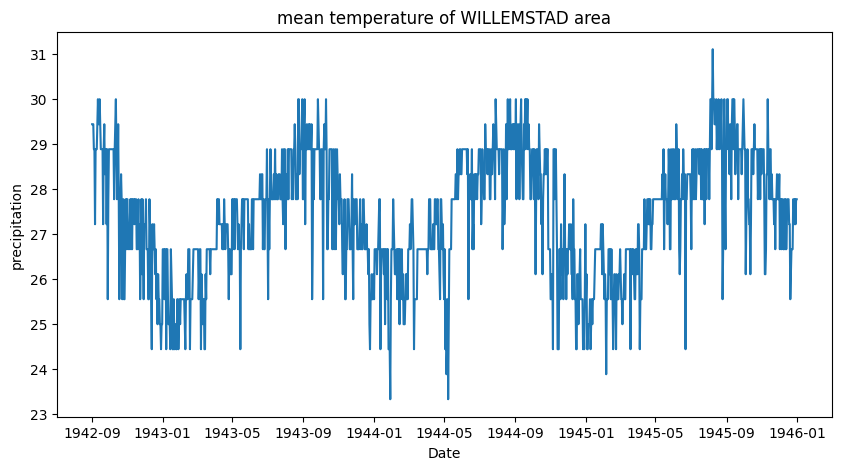

In [42]:
# 해당 지역의 평균 온도
plt.figure(figsize=(10, 5))
plt.plot(weather_ws.Date, weather_ws.MeanTemp)
plt.title("mean temperature of WILLEMSTAD area")
plt.xlabel("Date")
plt.ylabel("precipitation")
plt.show()

In [43]:
timeSeries_ws = weather_ws.loc[:, ["Date", "MeanTemp"]]
timeSeries_ws.index = timeSeries_ws.Date
ts_ws = timeSeries_ws.drop("Date", axis=1)
ts_ws

,MeanTemp
Date,
1942-09-01,29.444444
1942-09-02,29.444444
1942-09-03,29.444444
1942-09-04,28.888889
1942-09-05,28.888889
...,...
1945-12-27,27.222222
1945-12-28,27.777778
1945-12-29,27.222222


<Figure size 640x480 with 0 Axes>

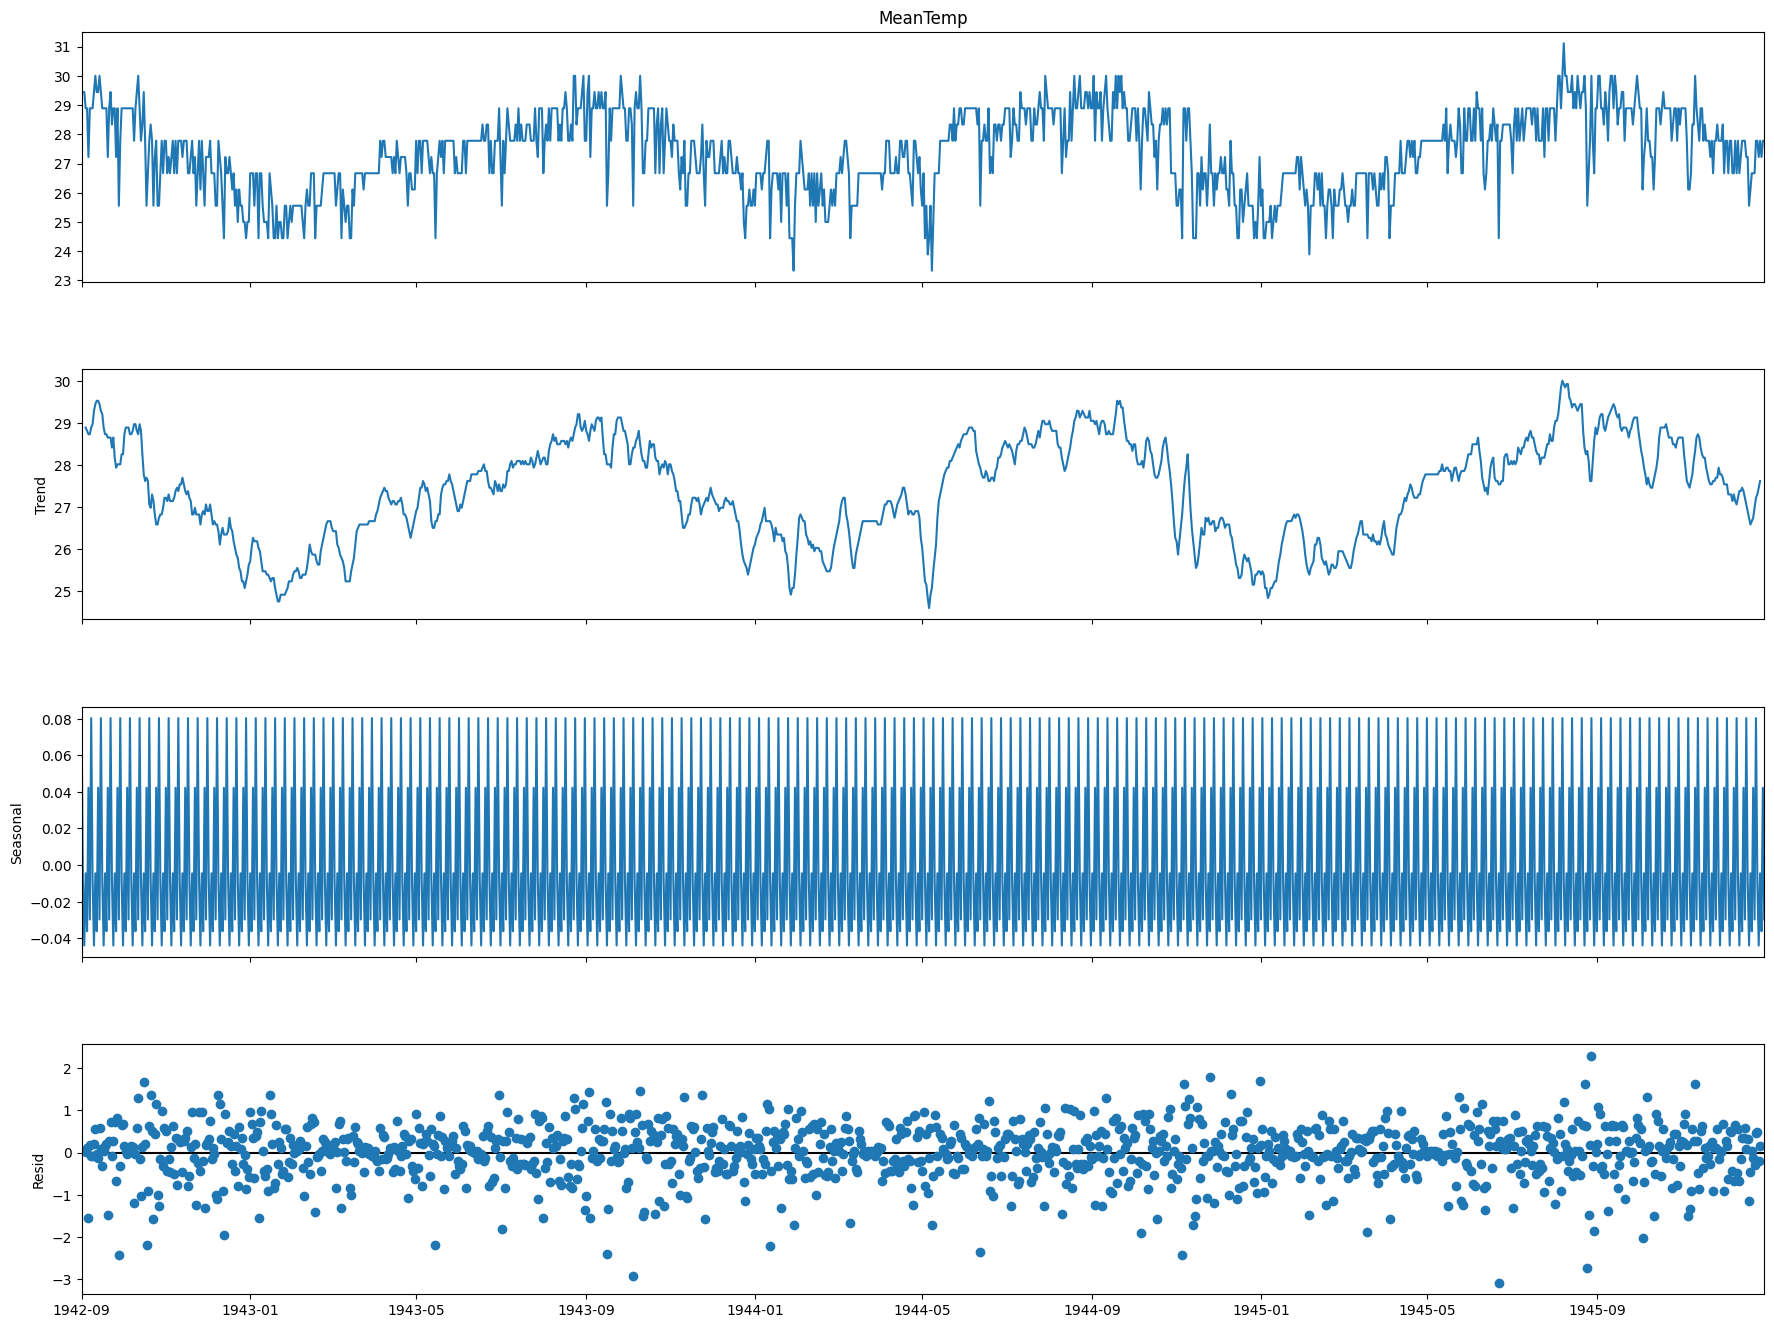

In [44]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 시계열 구성요소별 분리
result = seasonal_decompose(ts_ws["MeanTemp"], model='additive', period=7)

fig = plt.figure()
fig = result.plot()
fig.set_size_inches(20, 15)

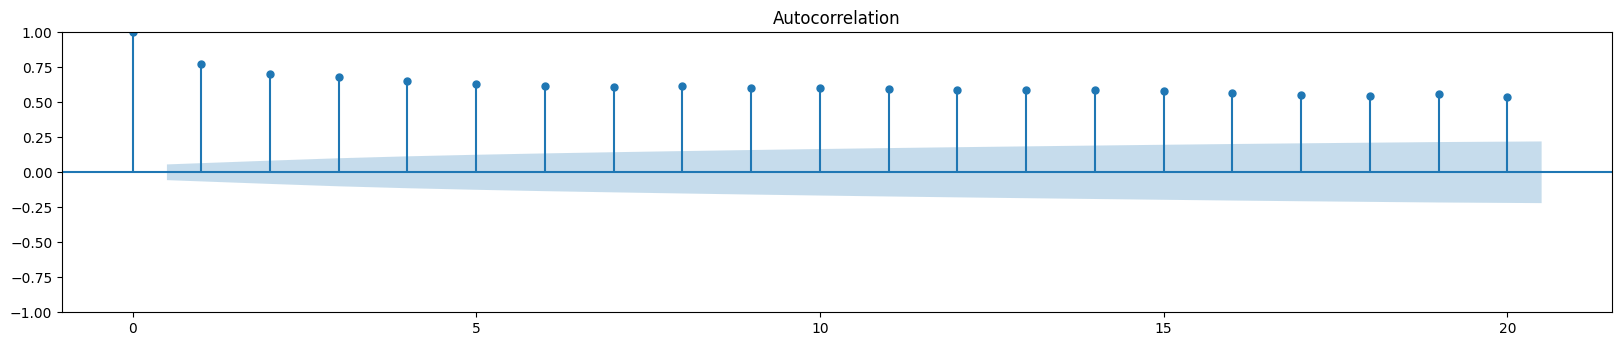

In [45]:
# 정상성 검증
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts_ws, lags=20, ax=ax1)

In [46]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(ts_ws)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -3.041994
p-value: 0.031154
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


p-value 가 0.031로, 귀무가설(비정상)을 기각한다. 즉, 위 시계열은 정상성을 만족하므로 차분을 추가적으로 하지 않는다.

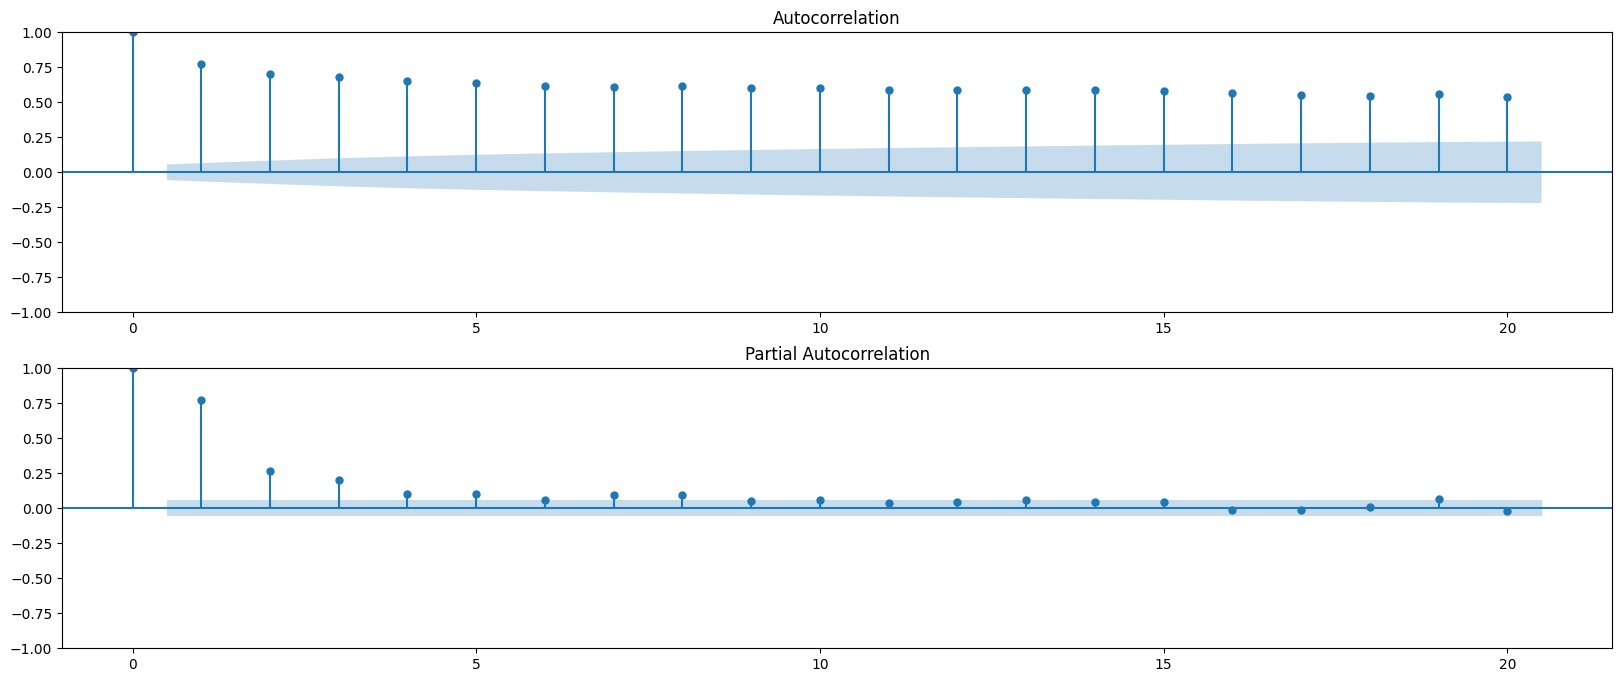

In [49]:
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts_ws[1:], lags=20, ax=ax1)

ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(ts_ws[1:], lags=20, ax=ax2)

ACF가 뚝 끊기는 부분 없이 천천히 감소하는 모습을 보인다. 따라서 q는 0으로 두고, PACF에서는 lag=2에서 급격히 감소하므로 p=2로 둔다.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


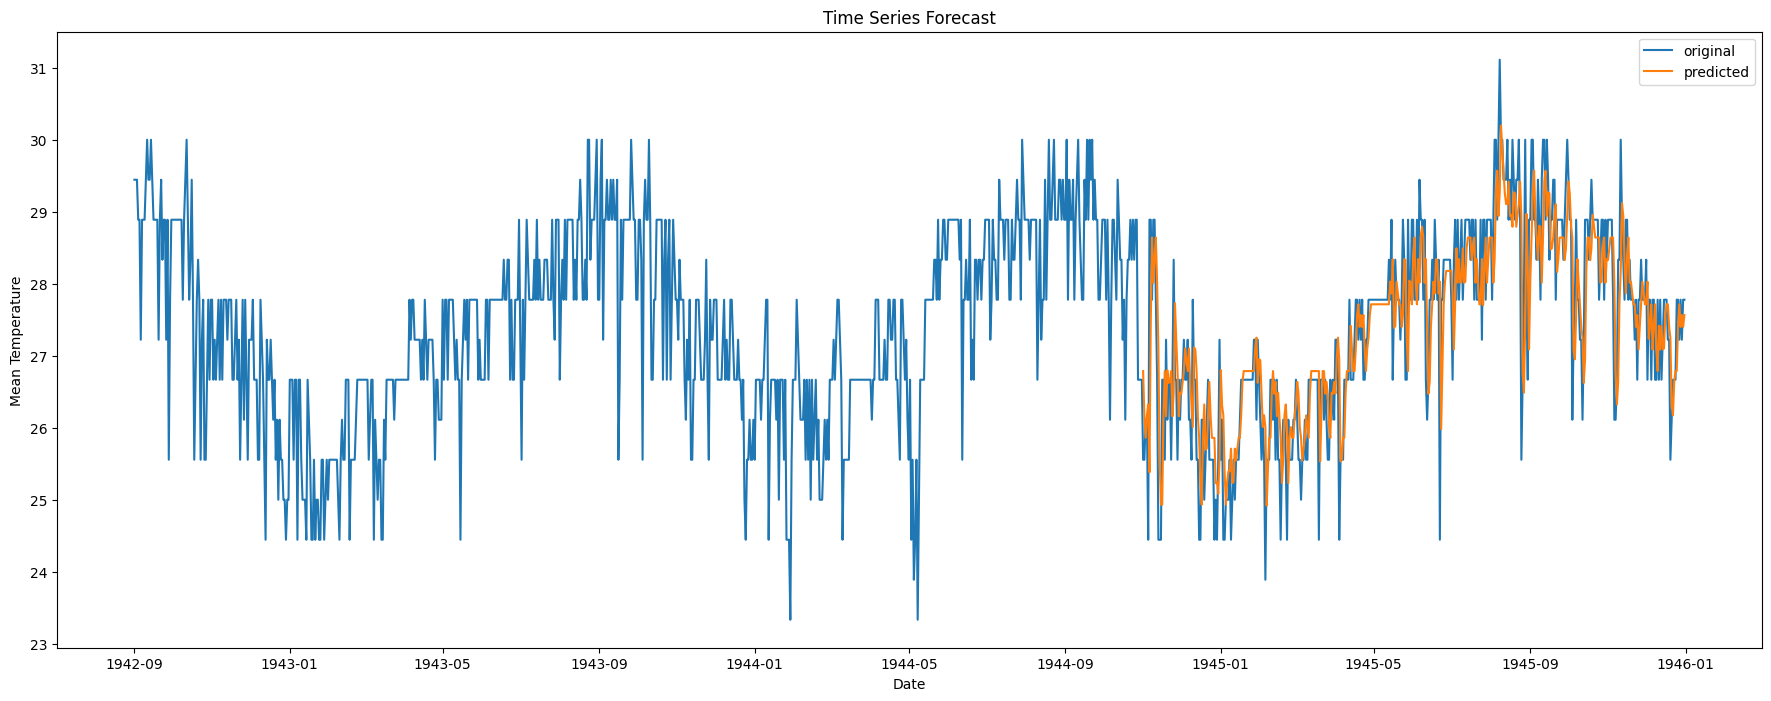

In [52]:
from statsmodels.tsa.arima.model import ARIMA
from datetime import datetime

## fit_this_code
p = 2
d = 0
q = 0

# fit model
model = ARIMA(ts_ws, order=(p,d,q))
model_fit = model.fit()

# predict
start_index = datetime(1944, 11, 1)
end_index = datetime(1945, 12, 31)
forecast = model_fit.predict(start=start_index, end=end_index, typ='levels')

# visualization
plt.figure(figsize=(22,8))
plt.plot(weather_ws.Date, weather_ws.MeanTemp, label="original")
plt.plot(forecast, label="predicted")
plt.title("Time Series Forecast")
plt.xlabel("Date")
plt.ylabel("Mean Temperature")
plt.legend()
plt.show()

/tmp/ipykernel_572/3093090623.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


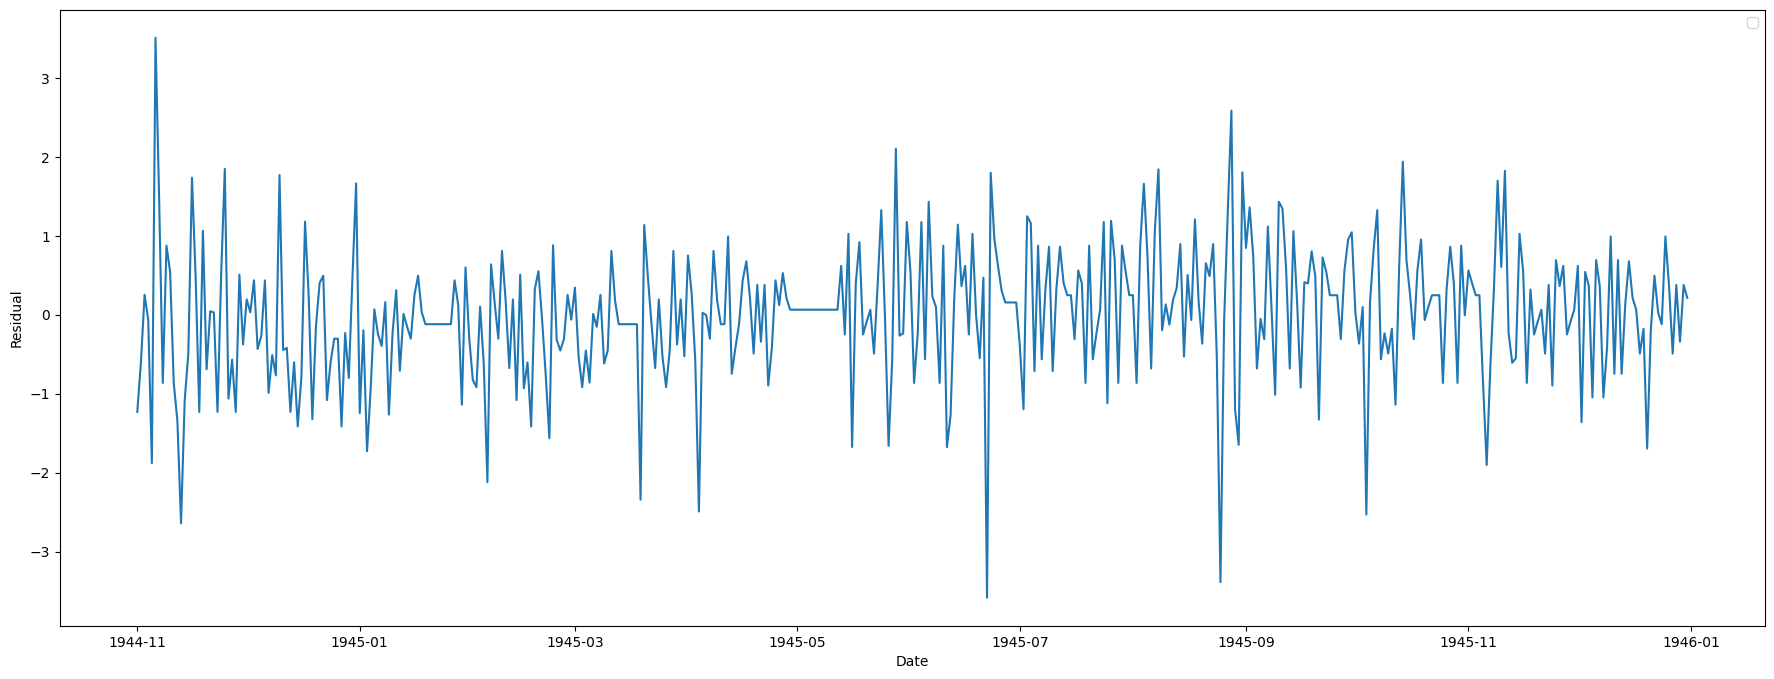

In [53]:
# 잔차 분석
resi = np.array(weather_ws[weather_ws.Date >= start_index].MeanTemp) - np.array(forecast)

plt.figure(figsize=(22,8))
plt.plot(weather_ws.Date[weather_ws.Date >= start_index], resi)
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.show()

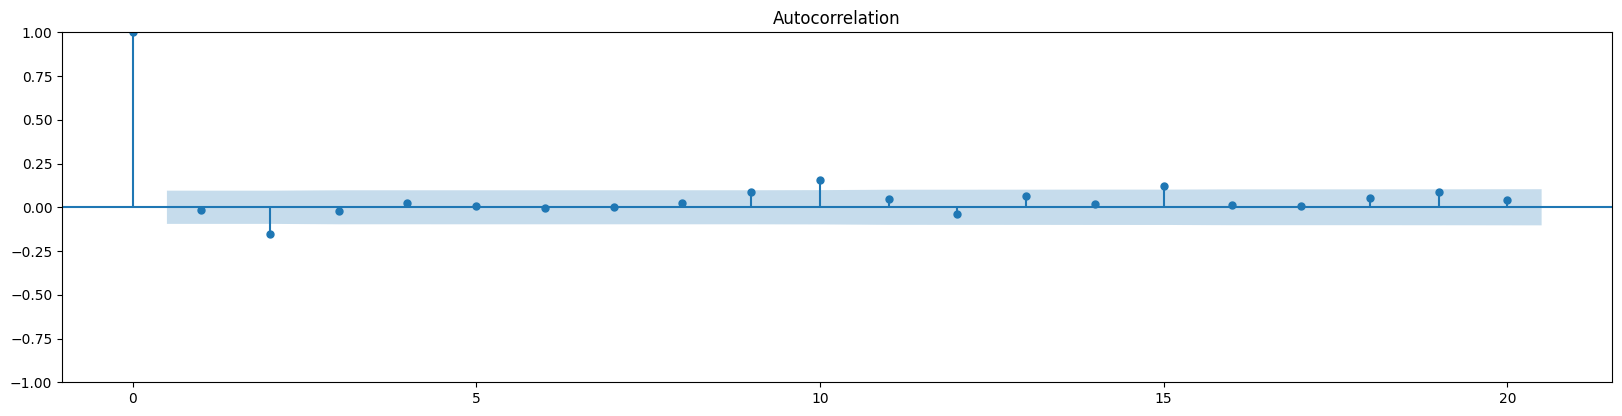

In [54]:
fig = plt.figure(figsize=(20,10))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(resi, lags=20, ax=ax1)

In [55]:
result = adfuller(resi)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
  print('\t%s: %.3f' % (key, value))

ADF Statistic: -2.958303
p-value: 0.038976
Critical Values:
	1%: -3.446
	5%: -2.869
	10%: -2.571


In [56]:
from sklearn import metrics

def scoring(y_true, y_pred):
  r2 = round(metrics.r2_score(y_true, y_pred) * 100, 3)
  corr = round(np.corrcoef(y_true, y_pred)[0, 1], 3)
  mape = round(
    metrics.mean_absolute_percentage_error(y_true, y_pred) * 100, 3
  )
  rmse = round(
    np.sqrt(metrics.mean_squared_error(y_true, y_pred)), 3
  )

  df = pd.DataFrame({
    "R2": r2,
    "Corr": corr,
    "RMSE": rmse,
    "MAPE": mape
  }, index=[0])

  return df

In [59]:
scoring(np.array(weather_ws[weather_ws.Date >= start_index].MeanTemp), np.array(forecast))

,R2,Corr,RMSE,MAPE
0,63.955,0.8,0.842,2.319


R2=63.955 이므로 모델이 실제 값의 약 64%의 분산을 설명하고 있다.

Corr는 상관계수로, 이 값이 0.8이라는 것은 예측값과 실제값 사이에 강한 양의 선형 관계가 존재한다는 것이다. 즉, 실제값이 예측 추세를 잘 따라간다고 볼 수 있다.

RMSE=0.842는 평균적으로 약 0.842정도의 오차가 발생한다는 것이며, 온도 단위를 고려하면 오차 규모가 매우 작은 편이다.

MAPE=2.319은 평균 절대 오차 비율이 약 2.3%라는 의미이다. 일반적으로 10% 이하면 우수한 예측 성능으로 평가되므로, 본 예측은 성능이 매우 우수하다고 판단할 수 있다.

In [94]:
# DLinear 모델
data = ts_ws.values

train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

seq_len = 365 # 입력 길이
pred_len = 30 # 예측 길이

class TimeSeriesDataset(Dataset):
  def __init__(self, data, seq_len, pred_len):
    self.data = data
    self.seq_len = seq_len
    self.pred_len = pred_len

  def __len__(self):
    return len(self.data) - self.seq_len - self.pred_len

  def __getitem__(self, idx):
    x = self.data[idx:idx+self.seq_len]
    y = self.data[idx+self.seq_len:idx+self.seq_len+self.pred_len]
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

train_dataset = TimeSeriesDataset(train_scaled, seq_len, pred_len)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)


class DLinear(nn.Module):
  def __init__(self, seq_len, pred_len, kernel_size=365):
    super().__init__()

    self.moving_avg = nn.AvgPool1d(
        kernel_size=kernel_size,
        stride=1,
        padding=kernel_size//2
    )

    self.linear_seasonal = nn.Linear(seq_len, pred_len)
    self.linear_trend = nn.Linear(seq_len, pred_len)

  def series_decomp(self, x):
    x = x.permute(0, 2, 1)
    trend = self.moving_avg(x)
    seasonal = x - trend
    return seasonal, trend

  def forward(self, x):
    seasonal, trend = self.series_decomp(x)
    seasonal = seasonal.squeeze(1)
    trend = trend.squeeze(1)
    return self.linear_seasonal(seasonal) + self.linear_trend(trend)

model = DLinear(seq_len, pred_len).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 100

for epoch in range(epochs):
  model.train()
  total_loss = 0

  for x, y in train_loader:
    x, y = x.to(device), y.to(device)

    optimizer.zero_grad()
    output = model(x)
    loss = criterion(output, y.squeeze(-1))
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  if (epoch+1) % 10 == 0:
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.6f}")

Epoch 10, Loss: 0.017615
Epoch 20, Loss: 0.014786
Epoch 30, Loss: 0.014186
Epoch 40, Loss: 0.013469
Epoch 50, Loss: 0.012971
Epoch 60, Loss: 0.013114
Epoch 70, Loss: 0.012082
Epoch 80, Loss: 0.012406
Epoch 90, Loss: 0.011584
Epoch 100, Loss: 0.011987


In [100]:
model.eval()

predictions = []

# walk-Forward Validation 방식으로 예측
# 시작 window: train 마지막 seq_len
current_window = train_scaled[-seq_len:].copy()

total_test_len = len(test_scaled)
t = 0

while t < total_test_len:
    x = torch.tensor(current_window, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(x).cpu().numpy().flatten()

    # 이번 블록에서 실제로 평가할 길이
    step = min(pred_len, total_test_len - t)

    predictions.extend(pred[:step])

    # window 업데이트를 예측값이 아니라 실제 test 값으로
    current_window = np.concatenate(
        [current_window[step:], test_scaled[t:t+step]],
        axis=0
    )

    t += step

# 역정규화
forecast_dl = scaler.inverse_transform(np.array(predictions).reshape(-1,1))

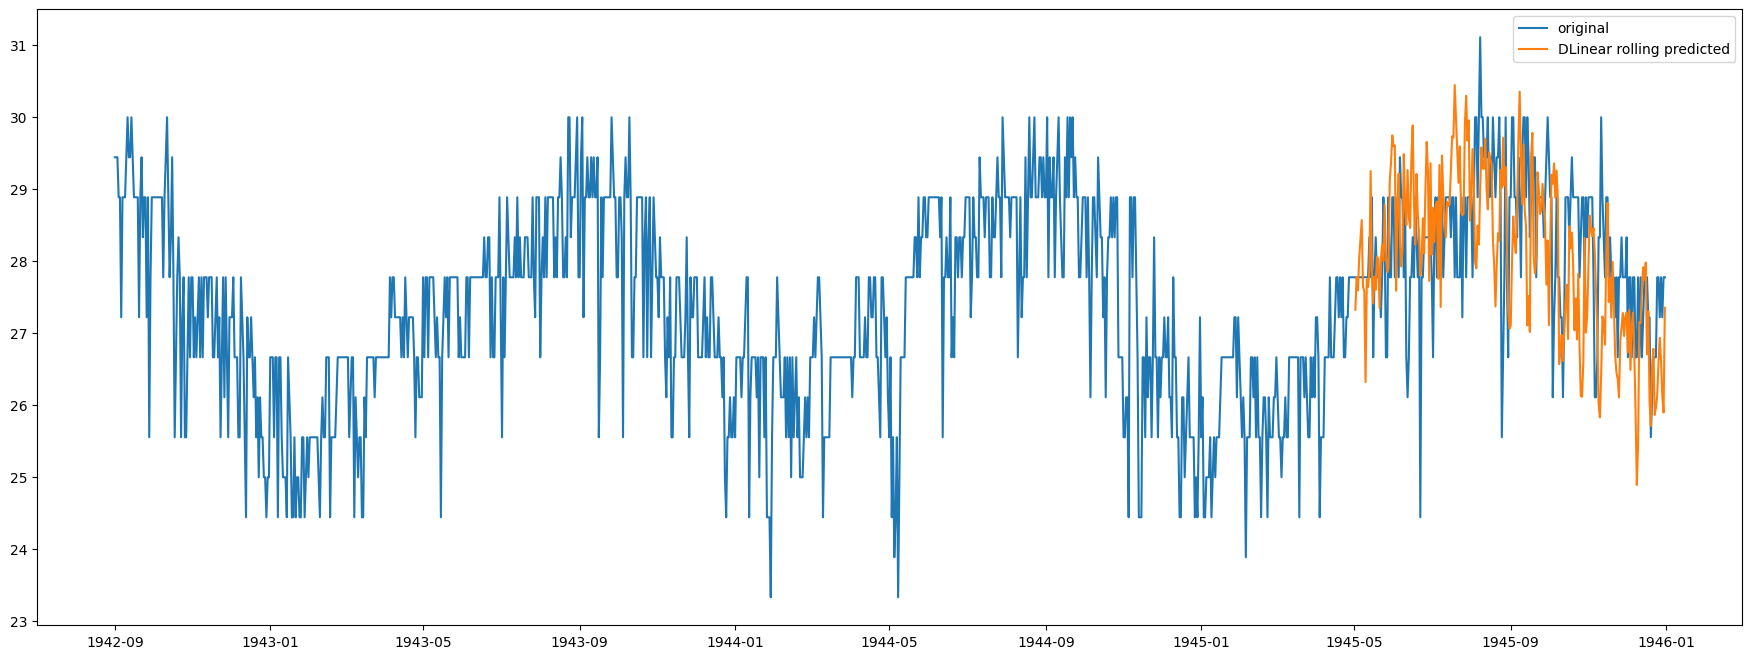

In [101]:
plt.figure(figsize=(22,8))
plt.plot(ts_ws.index, ts_ws.values, label="original")

test_dates = ts_ws.index[train_size:]
plt.plot(test_dates, forecast_dl.flatten(),label="DLinear rolling predicted")

plt.legend()
plt.show()

In [102]:
test_start_idx = train_size

y_true = ts_ws.values[test_start_idx:].reshape(-1)
y_pred = forecast_dl.reshape(-1)

print(y_true.shape, y_pred.shape)

scoring(y_true, y_pred)

(244,) (244,)


,R2,Corr,RMSE,MAPE
0,-52.635,0.314,1.229,3.48


R2 값이 여전히 큰 음수로 말도 안되는 값을 보이지만 나름대로의 보정을 한 결과이다(...) 파라미터 조정, 코드 수정 등의 보정을 시도했으나 오류를 해결하진 못했다.
